In [1]:
import json
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import sys
sys.path.append("../")
from src.preprocessing.pdf_extractor import PDFExtractor
from src.preprocessing.document_validator import DocumentValidator

In [2]:
# ---------------------------------------------------------
# LOAD FILES
# ---------------------------------------------------------

VOCAB_FILE = "../data/vocabulary/ministry_tfidf_vocab.json"
EMBED_FILE = "../data/embeddings/ministry_embeddings.json"


def load_vocab():
    with open(VOCAB_FILE, "r") as f:
        return json.load(f)


def load_embeddings():
    with open(EMBED_FILE, "r") as f:
        data = json.load(f)

    # convert to numpy
    for k in data:
        data[k] = np.array(data[k])

    return data

In [34]:
# ---------------------------------------------------------
# EXTRACT PARAGRAPHS FROM PDF
# ---------------------------------------------------------

def extract_paragraphs(pdf_path):

    extractor = PDFExtractor()
    result = extractor.extract(pdf_path)

    paragraphs = [seg["paragraph"] for seg in result["segments"]]
    speakers = [seg["speaker"] for seg in result["segments"]]

    return paragraphs, speakers

In [4]:
# ---------------------------------------------------------
# VALIDATE DOCUMENT
# ---------------------------------------------------------

def validate(text):

    validator = DocumentValidator(vocab_path="../data/vocabulary/parliament_vocab.txt")
    results = validator.validate_document(text)

    return results

In [5]:
# ---------------------------------------------------------
# VOCAB BASED CLASSIFICATION
# ---------------------------------------------------------

def classify_vocab(paragraph, ministry_vocab):

    words = paragraph.lower().split()

    scores = {}

    for ministry, vocab in ministry_vocab.items():

        count = 0

        for term in vocab:
            if term.lower() in paragraph.lower():
                count += 1

        scores[ministry] = count

    total = sum(scores.values()) + 1e-9

    probs = {k: v / total for k, v in scores.items()}

    return probs


# ---------------------------------------------------------
# EMBEDDING BASED CLASSIFICATION
# ---------------------------------------------------------

def classify_embedding(paragraph, model, ministry_embeddings):

    p_emb = model.encode(paragraph)

    scores = {}

    for ministry, m_emb in ministry_embeddings.items():

        sim = cosine_similarity(
            p_emb.reshape(1, -1),
            m_emb.reshape(1, -1)
        )[0][0]

        scores[ministry] = float(sim)

    # softmax normalization
    exp_scores = np.exp(list(scores.values()))
    probs = exp_scores / np.sum(exp_scores)

    return dict(zip(scores.keys(), probs))

In [35]:
# ---------------------------------------------------------
# MAIN PIPELINE
# ---------------------------------------------------------

def run_pipeline(pdf_path):

    print(f"Processing: {pdf_path}")
    print("-" * 50)

    paragraphs, speaker = extract_paragraphs(pdf_path)

    full_text = "\n\n".join(paragraphs)

    validation = validate(full_text)

    print("VALIDATION RESULTS:")
    print(json.dumps(validation, indent=4))

    if not validation["is_valid"]:
        print("Document failed validation")
        return

    print("\nLoading ministry vocab...")
    ministry_vocab = load_vocab()

    print("Loading ministry embeddings...")
    ministry_embeddings = load_embeddings()

    model = SentenceTransformer("all-MiniLM-L6-v2", cache_folder="../models")

    print("\nClassifying paragraphs...\n")

    results = []

    for i, para in enumerate(paragraphs):

        vocab_probs = classify_vocab(para, ministry_vocab)

        embed_probs = classify_embedding(
            para,
            model,
            ministry_embeddings
        )

        results.append({
            "paragraph_id": i,
            "paragraph": para[:200],
            "speaker": speaker[i],
            "vocab_distribution": vocab_probs,
            "embedding_distribution": embed_probs
        })

        print("=" * 80)
        print(f"Paragraph {i}")
        # print(para[:200])

        print("\nTop vocab ministry:")
        print(sorted(vocab_probs.items(), key=lambda x: x[1], reverse=True)[:3])

        print("\nTop embedding ministry:")
        print(sorted(embed_probs.items(), key=lambda x: x[1], reverse=True)[:3])

    return results

In [36]:
# ---------------------------------------------------------
# RUN
# ---------------------------------------------------------

# if __name__ == "__main__":

file_name = "test.pdf"
file_path = f"../data/uploads/{file_name}"

results = run_pipeline(file_path)

Processing: ../data/uploads/test.pdf
--------------------------------------------------
VALIDATION RESULTS:
{
    "is_valid": true,
    "is_english": true,
    "validation_errors": [],
    "vocab_size": 116,
    "required_vocab_matches": 5,
    "parliament_confidence": 0.09482758620689655,
    "matched_vocab_terms": [
        "act",
        "bill",
        "budget",
        "finance bill",
        "gazette",
        "government",
        "half",
        "motion",
        "motion of thanks",
        "schedule",
        "speaker"
    ]
}

Loading ministry vocab...
Loading ministry embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Classifying paragraphs...

Paragraph 0

Top vocab ministry:
[('Ministry_of_Parliamentary_Affairs_MPA_', 0.49999999991666666), ('Ministry_of_Law_and_Justice_MoLJ_', 0.16666666663888888), ('Ministry_of_Minority_Affairs_MoMA_', 0.16666666663888888)]

Top embedding ministry:
[('Ministry_of_Home_Affairs_MHA_', np.float64(0.021151059906757398)), ('Ministry_of_Parliamentary_Affairs_MPA_', np.float64(0.021085025986886965)), ('Ministry_of_Labour_and_Employment_MoLE_', np.float64(0.02078251271932788))]
Paragraph 1

Top vocab ministry:
[('Ministry_of_Parliamentary_Affairs_MPA_', 0.33333333327777775), ('Ministry_of_Textiles_MoT_', 0.16666666663888888), ('Ministry_of_Development_of_North_Eastern_Region_MDoNER_', 0.16666666663888888)]

Top embedding ministry:
[('Ministry_of_Personnel_Public_Grievances_and_Pensions_MoPPGP_', np.float64(0.02075773015031245)), ('Ministry_of_Science_and_Technology_MST_', np.float64(0.02059503624578871)), ('Ministry_of_Heavy_Industries_MoHI_', np.float64(0.0205260781736

In [8]:
import numpy as np

def compute_document_distribution(results, method="embedding"):
    
    ministry_scores = {}

    for item in results:

        if method == "embedding":
            dist = item["embedding_distribution"]
        else:
            dist = item["vocab_distribution"]

        for ministry, prob in dist.items():
            ministry_scores[ministry] = ministry_scores.get(ministry, 0) + prob

    # normalize
    total = sum(ministry_scores.values())

    ministry_scores = {
        k: v / total
        for k, v in ministry_scores.items()
    }

    return ministry_scores

In [9]:
def print_top_ministries(distribution, top_k=10):

    sorted_min = sorted(
        distribution.items(),
        key=lambda x: x[1],
        reverse=True
    )

    print("\nTOP MINISTRIES IN DOCUMENT\n")

    for ministry, score in sorted_min[:top_k]:
        print(f"{ministry:40} {score:.4f}")

In [10]:
import matplotlib.pyplot as plt

def plot_ministry_distribution(distribution, top_k=10):

    sorted_min = sorted(
        distribution.items(),
        key=lambda x: x[1],
        reverse=True
    )[:top_k]

    ministries = [x[0] for x in sorted_min]
    scores = [x[1] for x in sorted_min]

    plt.figure(figsize=(12,6))

    plt.barh(ministries, scores)

    plt.xlabel("Probability")
    plt.title("Document Ministry Distribution")

    plt.gca().invert_yaxis()

    plt.show()

In [11]:
def plot_comparison(vocab_dist, embed_dist, top_k=10):

    vocab_sorted = sorted(vocab_dist.items(), key=lambda x: x[1], reverse=True)[:top_k]
    embed_sorted = sorted(embed_dist.items(), key=lambda x: x[1], reverse=True)[:top_k]

    ministries = [x[0] for x in embed_sorted]

    vocab_scores = [vocab_dist.get(m,0) for m in ministries]
    embed_scores = [embed_dist.get(m,0) for m in ministries]

    x = np.arange(len(ministries))

    plt.figure(figsize=(12,6))

    plt.bar(x-0.2, vocab_scores, width=0.4, label="Vocab")
    plt.bar(x+0.2, embed_scores, width=0.4, label="Embedding")

    plt.xticks(x, ministries, rotation=60)
    plt.ylabel("Score")

    plt.title("Ministry Distribution Comparison")

    plt.legend()

    plt.show()

In [19]:
def build_heatmap_matrix(results, method="embedding"):

    ministries = list(results[0][f"{method}_distribution"].keys())
    num_paragraphs = len(results)

    matrix = np.zeros((len(ministries), num_paragraphs))

    for j, para in enumerate(results):

        dist = para[f"{method}_distribution"]

        for i, ministry in enumerate(ministries):

            matrix[i, j] = dist[ministry]

    return matrix, ministries

import matplotlib.pyplot as plt

def plot_ministry_heatmap(matrix, ministries):

    plt.figure(figsize=(16,8))

    plt.imshow(matrix, aspect='auto')

    plt.colorbar(label="Ministry Relevance")

    plt.ylabel("Ministries")
    plt.xlabel("Paragraph Index")

    plt.yticks(range(len(ministries)), ministries)

    plt.title("Ministry Discussion Heatmap Across Paragraphs")

    plt.show()

In [12]:
vocab_doc_dist = compute_document_distribution(results, "vocab")
embed_doc_dist = compute_document_distribution(results, "embedding")

print_top_ministries(embed_doc_dist)


TOP MINISTRIES IN DOCUMENT

Ministry_of_Rural_Development_MoRD_      0.0201
Ministry_of_Finance_MoF_                 0.0199
Ministry_of_Planning_MoP_                0.0198
Ministry_of_Railways_MoR_                0.0197
Ministry_of_Parliamentary_Affairs_MPA_   0.0196
Ministry_of_Tribal_Affairs_MoTA_         0.0196
Ministry_of_Personnel_Public_Grievances_and_Pensions_MoPPGP_ 0.0195
Ministry_of_Women_and_Child_Development_MoWCD_ 0.0194
Ministry_of_Social_Justice_and_Empowerment_MoSJE_ 0.0193
Ministry_of_Commerce_and_Industry_MoCI_  0.0193


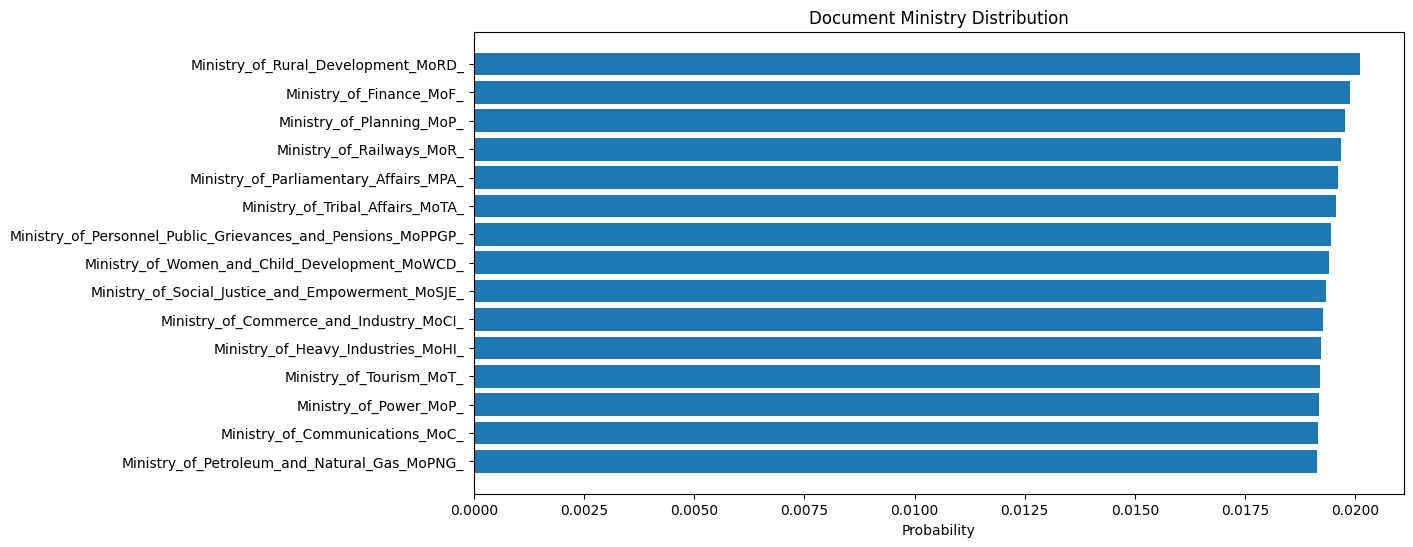

In [16]:
plot_ministry_distribution(embed_doc_dist, top_k=15)

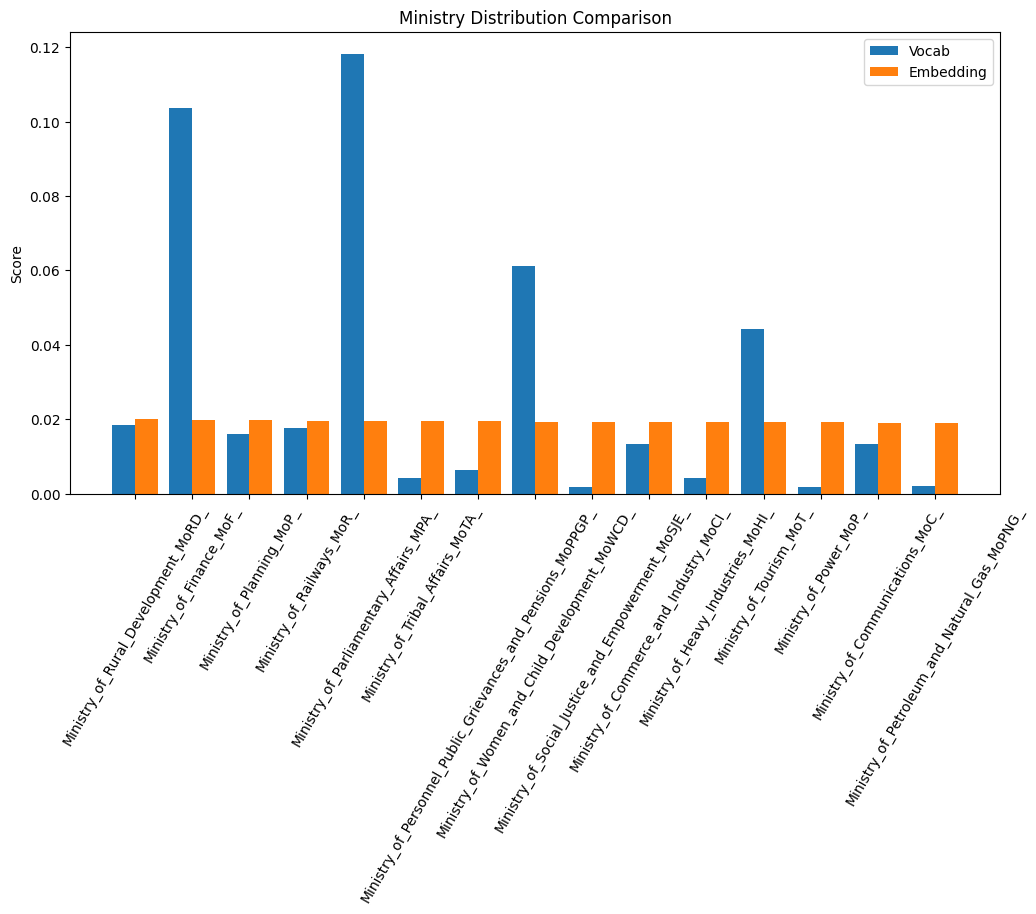

In [17]:
plot_comparison(vocab_doc_dist, embed_doc_dist, top_k=15)

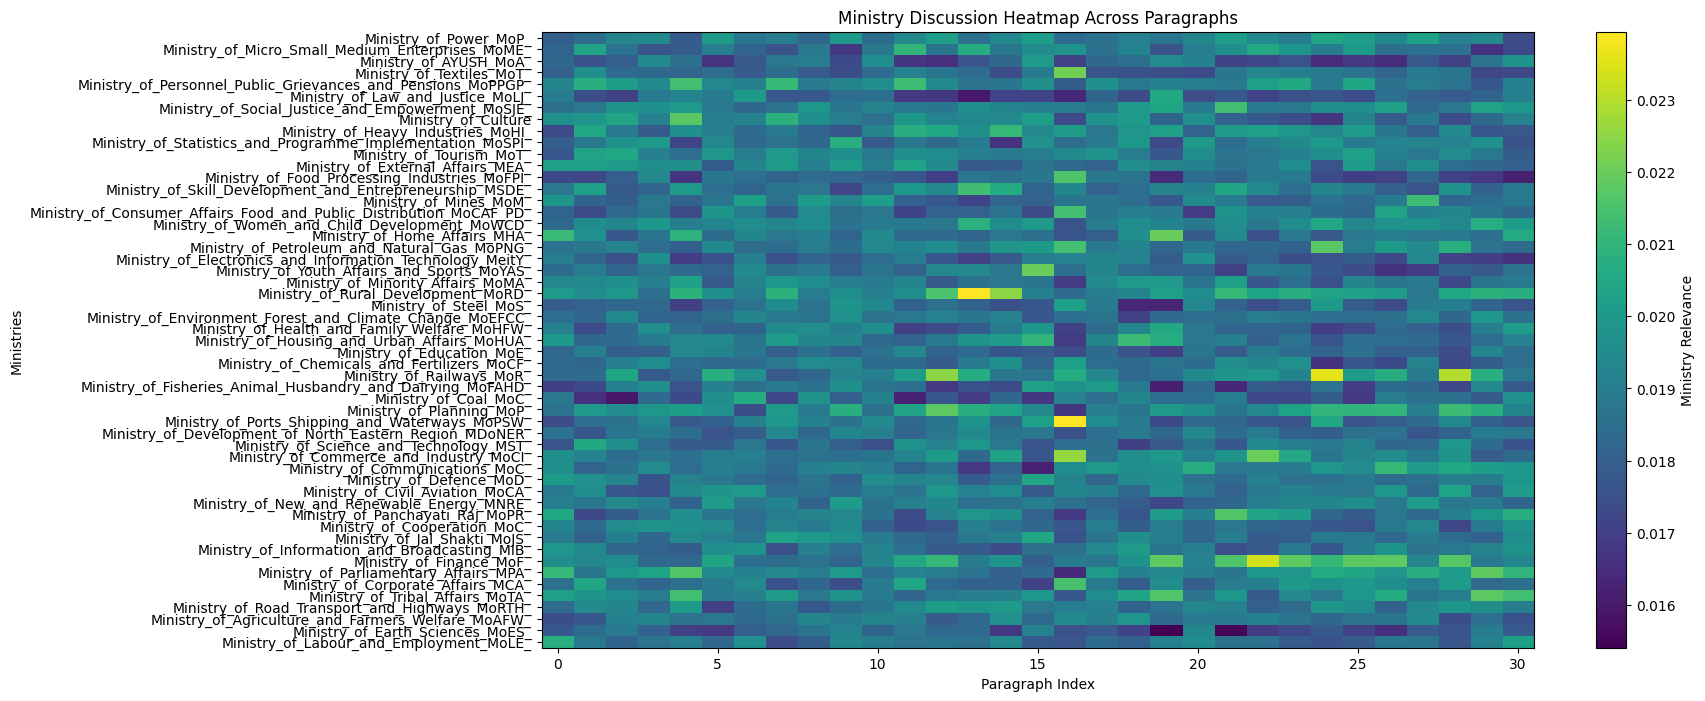

In [20]:
matrix, ministries = build_heatmap_matrix(results, "embedding")

plot_ministry_heatmap(matrix, ministries)

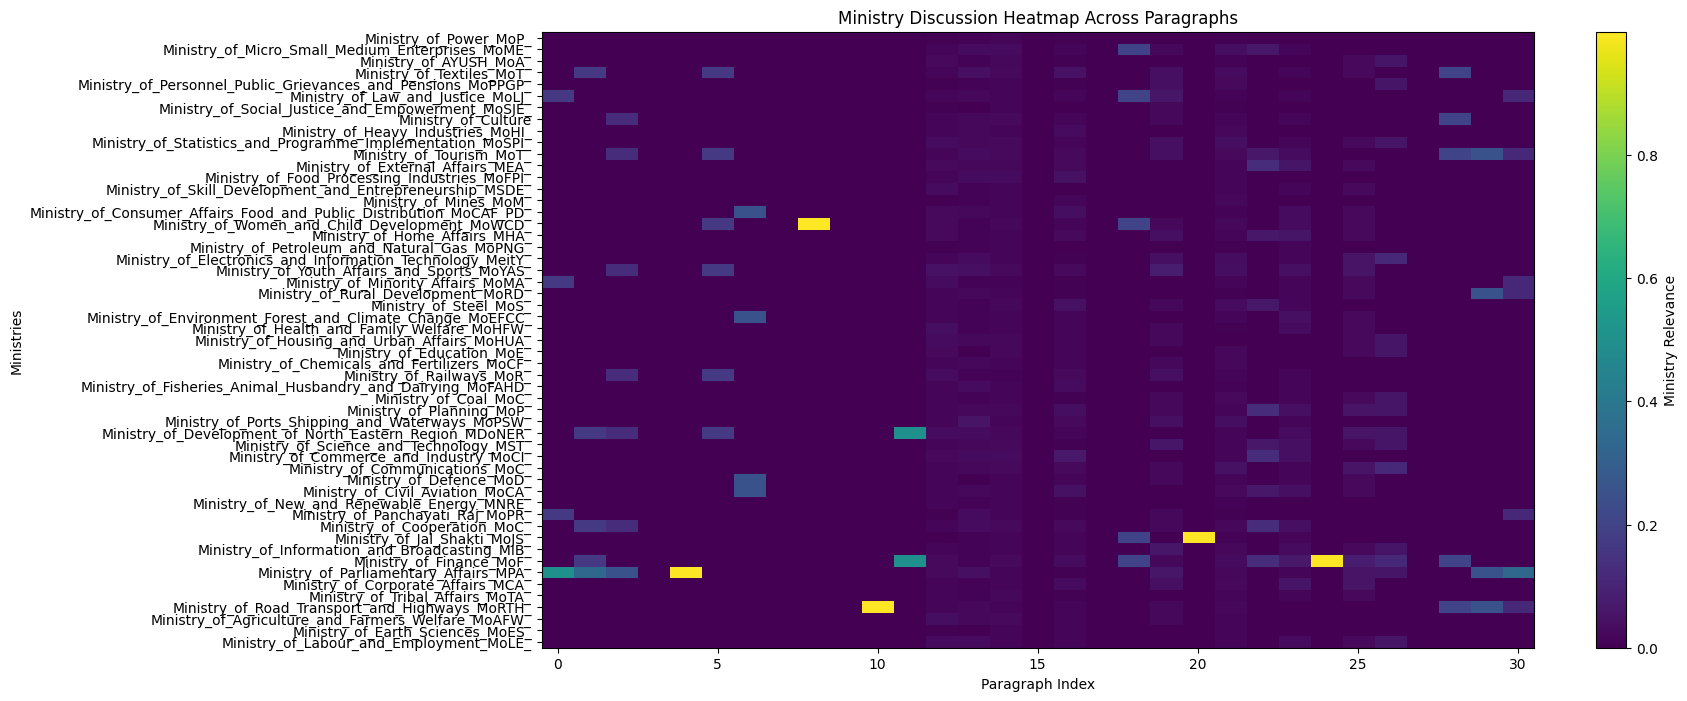

In [23]:
matrix, ministries = build_heatmap_matrix(results, "vocab")

plot_ministry_heatmap(matrix, ministries)

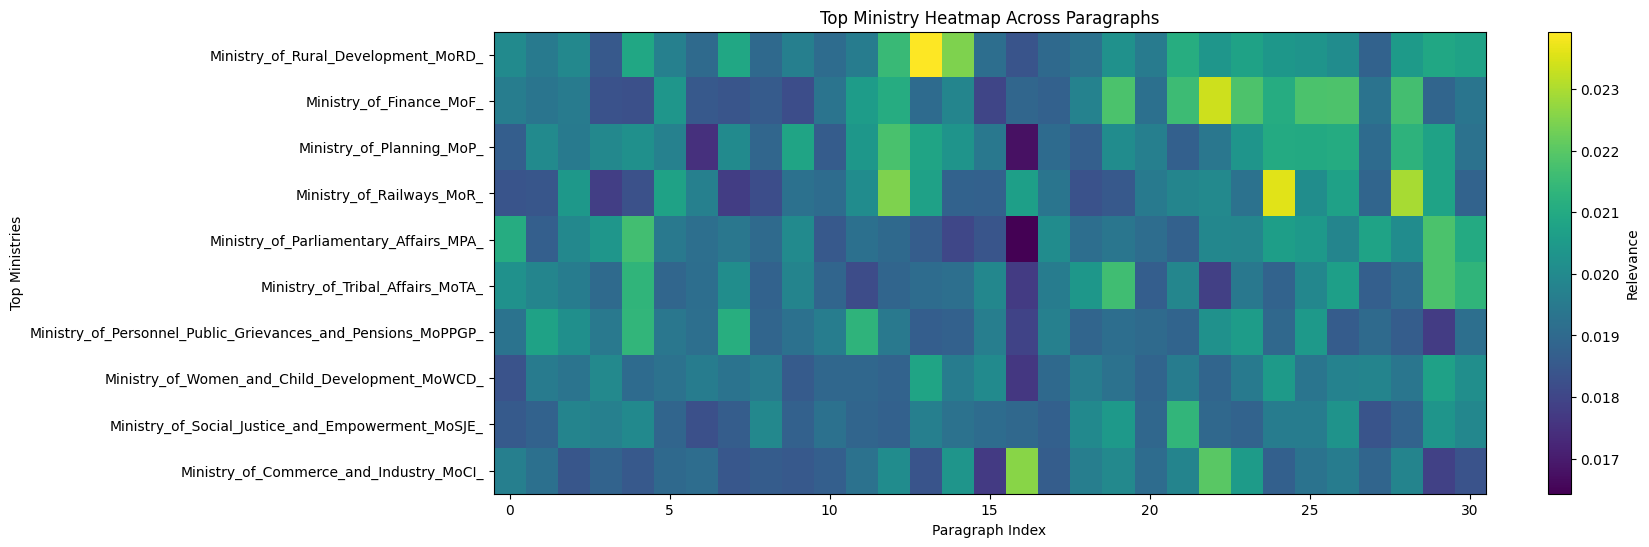

In [21]:
def plot_top_ministry_heatmap(matrix, ministries, top_k=10):

    ministry_scores = matrix.sum(axis=1)

    top_idx = np.argsort(ministry_scores)[::-1][:top_k]

    top_matrix = matrix[top_idx]
    top_ministries = [ministries[i] for i in top_idx]

    plt.figure(figsize=(16,6))

    plt.imshow(top_matrix, aspect='auto')

    plt.colorbar(label="Relevance")

    plt.yticks(range(top_k), top_ministries)

    plt.xlabel("Paragraph Index")
    plt.ylabel("Top Ministries")

    plt.title("Top Ministry Heatmap Across Paragraphs")

    plt.show()
    
matrix, ministries = build_heatmap_matrix(results)

plot_top_ministry_heatmap(matrix, ministries)

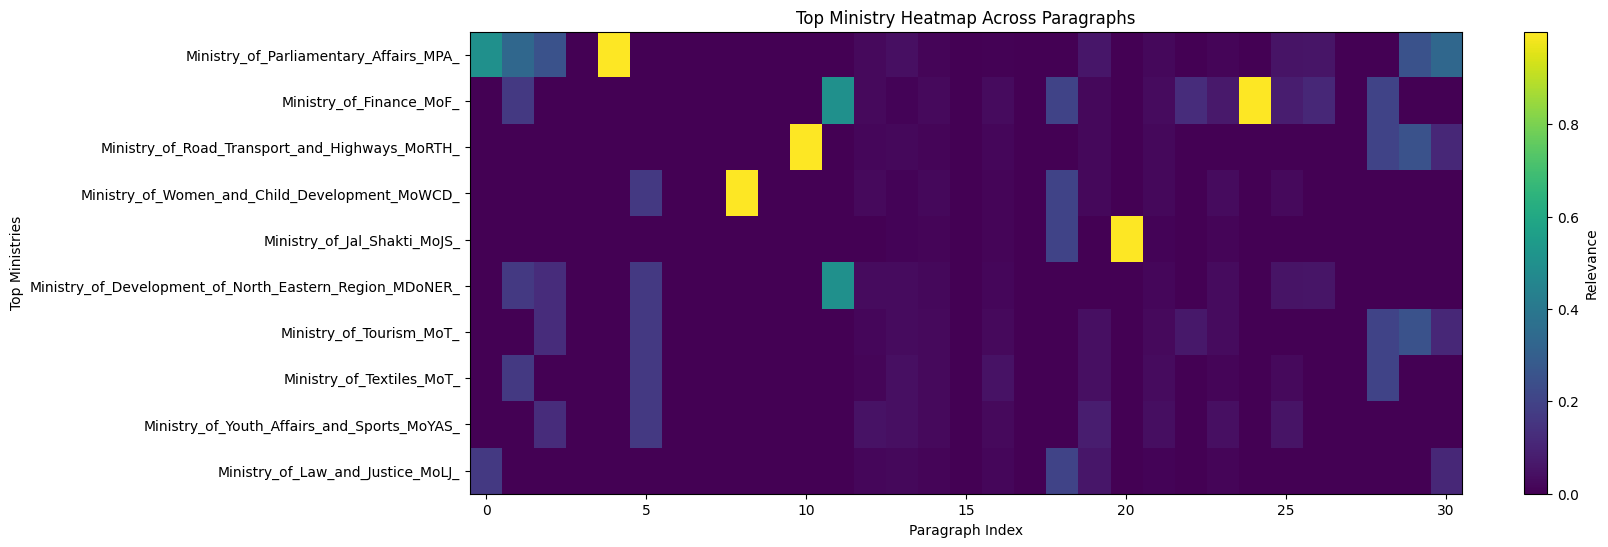

In [22]:
matrix, ministries = build_heatmap_matrix(results, method="vocab")

plot_top_ministry_heatmap(matrix, ministries)

In [37]:
from collections import defaultdict

def build_speaker_ministry_matrix(results, method="embedding"):

    speaker_ministry = defaultdict(lambda: defaultdict(float))

    for item in results:

        speaker = item["speaker"]

        dist = item[f"{method}_distribution"]

        for ministry, prob in dist.items():
            speaker_ministry[speaker][ministry] += prob

    speakers = list(speaker_ministry.keys())
    ministries = list(next(iter(speaker_ministry.values())).keys())

    matrix = np.zeros((len(speakers), len(ministries)))

    for i, spk in enumerate(speakers):
        for j, minstry in enumerate(ministries):

            matrix[i, j] = speaker_ministry[spk][minstry]

    return matrix, speakers, ministries

In [38]:
def select_top_ministries(matrix, ministries, top_k=10):

    scores = matrix.sum(axis=0)

    top_idx = np.argsort(scores)[::-1][:top_k]

    new_matrix = matrix[:, top_idx]

    new_ministries = [ministries[i] for i in top_idx]

    return new_matrix, new_ministries

In [39]:
import seaborn as sns

def plot_speaker_ministry_heatmap(matrix, speakers, ministries):

    plt.figure(figsize=(14,8))

    sns.heatmap(
        matrix,
        xticklabels=ministries,
        yticklabels=speakers,
        cmap="YlOrRd"
    )

    plt.xlabel("Ministry")
    plt.ylabel("Speaker")

    plt.title("Speaker × Ministry Discussion Heatmap")

    plt.show()

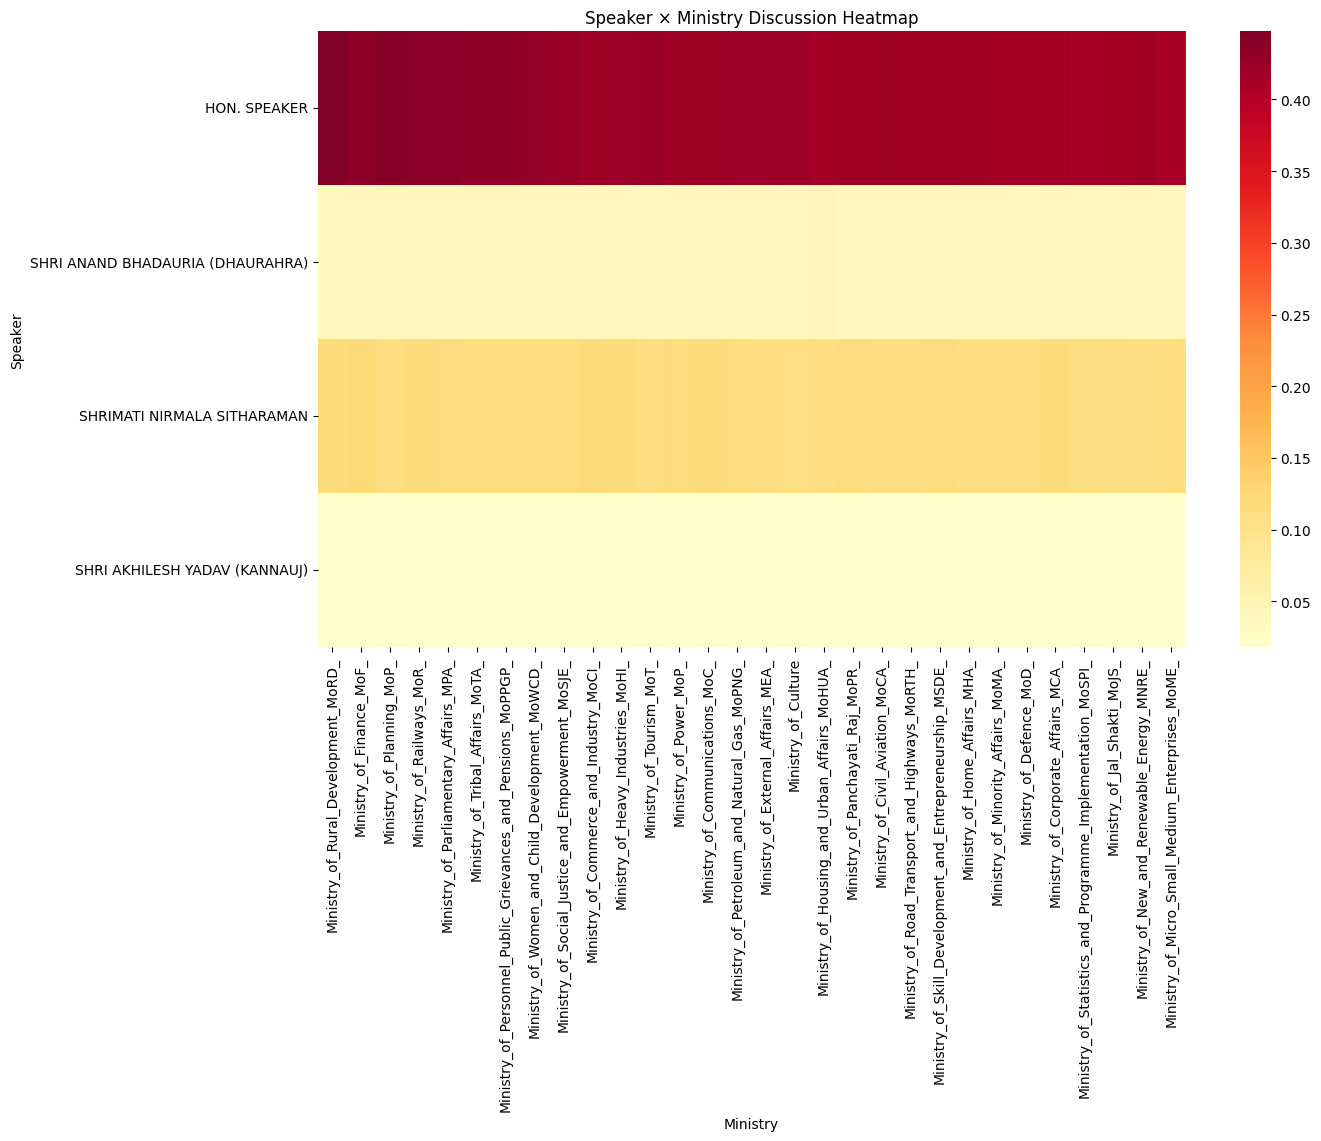

In [43]:
matrix, speakers, ministries = build_speaker_ministry_matrix(results, method="embedding")

matrix, ministries = select_top_ministries(matrix, ministries, top_k=30)

plot_speaker_ministry_heatmap(matrix, speakers, ministries)

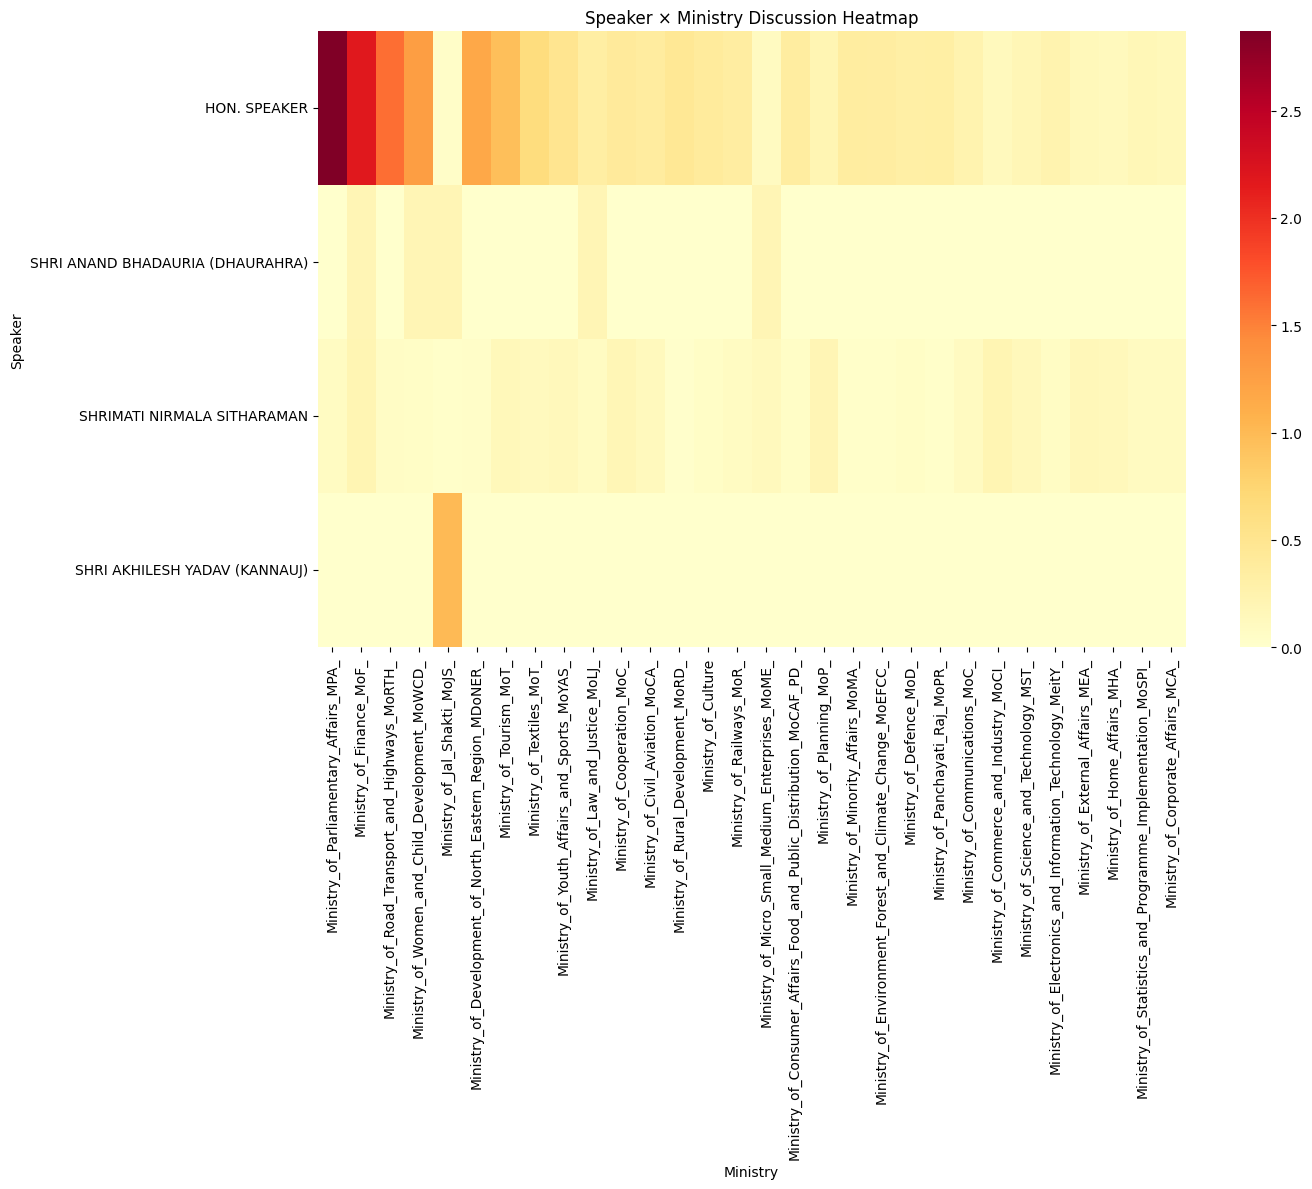

In [42]:
matrix, speakers, ministries = build_speaker_ministry_matrix(results, method="vocab")

matrix, ministries = select_top_ministries(matrix, ministries, top_k=30)

plot_speaker_ministry_heatmap(matrix, speakers, ministries)